# Analytical Fourier Series Gibb affect and Quadrature estimations

This notebooks aims to outline the potential limitation with using the Fourier series solution and different Quadrature techniques to estimate total settlement.

### Fourier series verification 
checking that the generalised arbitrary u0 analytical solver collapses to the classical Terzaghi series for a uniform initial excess pore pressure and Boussinesq initial conditions.


### Quadrature introduction 
introduction into quadrature introduction and implications



In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os, sys
project_root = os.path.abspath(os.path.join('..'))
sys.path.insert(0, project_root)

from src.geotech_consolidation.models.terzaghi_1d.analytical import Get_terzaghi1d_Analytical
from src.geotech_consolidation.models.terzaghi_1d.u0_analytical import Get_terzaghi1d_Analytical_u0


def boussinesq_strip_u0(z, load, base):
    z_safe = np.maximum(z, 1e-12)
    u0 = (2.0 * load / np.pi) * (
        np.arctan(base / (2.0 * z_safe)) +
        (base * z_safe) / (2.0 * z_safe**2 + 0.5 * base**2)
    )
    u0[np.isclose(z, 0.0)] = 0.0
    return u0

def error_metrics(reference, candidate):
    diff = reference - candidate
    rmse = np.sqrt(np.mean(diff**2))
    norm_l2 = np.sqrt(np.sum(diff**2) / (np.sum(reference**2) + 1e-12))
    return {"rmse": rmse, "norm_l2": norm_l2}

sns.set_theme(style="whitegrid")

H = 5.0   
num = 50        
nodes = num + 1
load = 100.0      # (kPa)
base = 3.0       
Cv = 2e-7         # (m²/s)
Mv = 5e-4         #  (m²/kN)
final_time = (24 * 60 * 60) * 365   # total time (s)
time_steps = 1000

# arrays used for plotting 
depth      = np.linspace(0.0, H, nodes)
time_days  = np.linspace(0, final_time / (60 * 60 * 24), time_steps)

# Permebaility 
gamma_w = 9.81   
k = Cv * Mv * gamma_w
print(f"Cv = {Cv:.2e} m²/s")
print(f"k  = {k:.2e} m/s ")

Cv = 2.00e-07 m²/s
k  = 9.81e-10 m/s 


## Uniform Initial Condition

using a uniform initial excess pore pressure (of 100 kPa), the generalised arbitrary u0 solver must reproduce the classical Terzaghi series. Any small oscillation near the surface is a Gibbs effect from the Fourier truncation at the drained boundary, not an error.


In [16]:
uniform_u0 = np.full(nodes, load, dtype=float)
N_terms = int(np.round(0.8 * num))

cdata_std, u_std, depth_std, time_std = Get_terzaghi1d_Analytical( H, num, load, final_time, time_steps, Cv, N_terms)
u_u0_uniform, _, _ = Get_terzaghi1d_Analytical_u0(uniform_u0, H, num, final_time, time_steps, Cv, N_terms)

error_t0_arb  = error_metrics(u_std[0],  uniform_u0) # error at t = 0
error_t0_uniform = error_metrics(u_u0_uniform[0],  uniform_u0) # error at t = 0

dif_final_time = error_metrics(u_std[-1], u_u0_uniform[-1]) # error at t = last time step (Final time)
dif_0_time = error_metrics(u_std[0], u_u0_uniform[0]) # error at t = last time step (Final time)

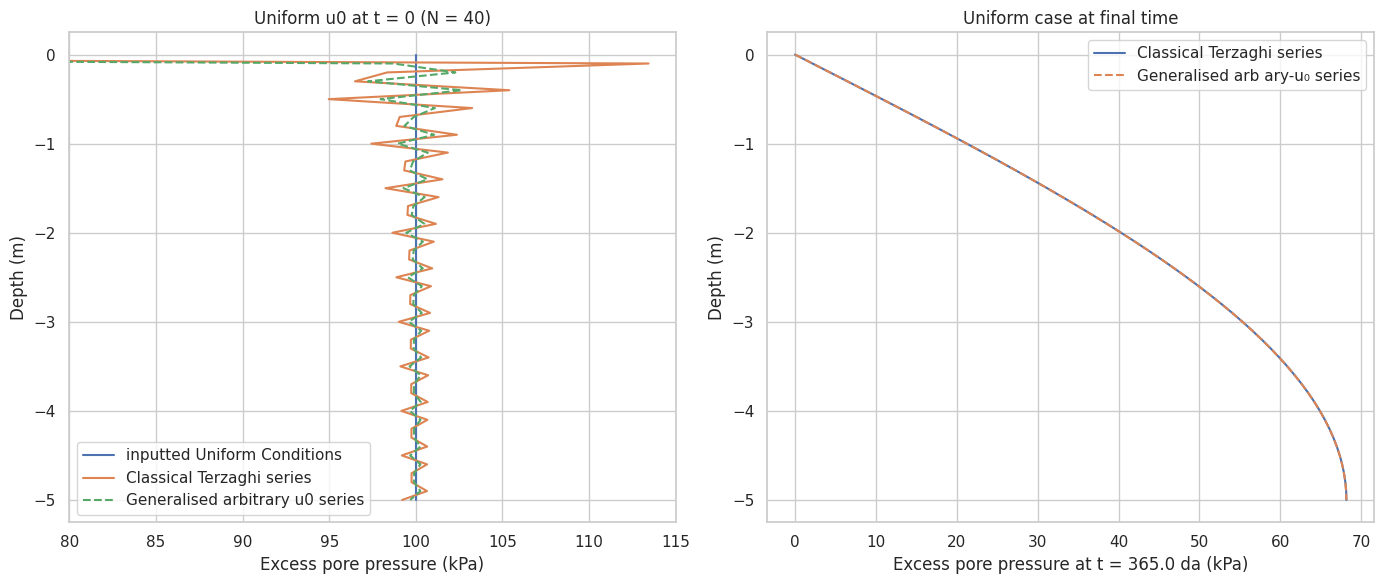

case (uniform)              : t = 0.     L2 norm: 0.143206,  RSME: 14.213341
case (arbitrary)            : t = 0.     L2 norm: 0.141672,  RSME: 14.026732
difference between Uu and U0: t = 0      L2 norm: 0.023123,  RSME: 2.294958
difference between Uu and U0: t = final  L2 norm: 0.000082,  RSME: 0.003973


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(uniform_u0, -depth_std, label = 'inputted Uniform Conditions')
axes[0].plot(u_std[0], -depth_std, label="Classical Terzaghi series")
axes[0].plot(u_u0_uniform[0], -depth, linestyle = "--", label="Generalised arbitrary u0 series")
axes[0].set_xlabel("Excess pore pressure (kPa)")
axes[0].set_xlim(0.8 * load, 1.15 * load)
axes[0].set_ylabel("Depth (m)")
axes[0].set_title(f"Uniform u0 at t = 0 (N = {N_terms})")
axes[0].legend(loc = "lower left")

axes[1].plot(u_std[-1],        -depth_std, label="Classical Terzaghi series")
axes[1].plot(u_u0_uniform[-1], -depth,    "--", label="Generalised arb ary-u₀ series")
axes[1].set_xlabel(f"Excess pore pressure at t = {time_std[-1]:.1f} da (kPa)")
axes[1].set_ylabel("Depth (m)")
axes[1].set_title("Uniform case at final time")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'case (uniform)              : t = 0.     L2 norm: {error_t0_arb["norm_l2"]:.6f},  RSME: {error_t0_arb["rmse"]:.6f}')
print(f'case (arbitrary)            : t = 0.     L2 norm: {error_t0_uniform["norm_l2"]:.6f},  RSME: {error_t0_uniform["rmse"]:.6f}')

print(f'difference between Uu and U0: t = 0      L2 norm: {dif_0_time["norm_l2"]:.6f},  RSME: {dif_0_time["rmse"]:.6f}')
print(f'difference between Uu and U0: t = final  L2 norm: {dif_final_time["norm_l2"]:.6f},  RSME: {dif_final_time["rmse"]:.6f}')

It was found for the generalised arbitrary u0 analytical solver keep the n number the same as the node or cell number keeps it the most optimised for given initial conditions when seen compared  against uniform conditions, and thus is less computionly heavy. This is shortly explained in the next section.
majority of the error observed at t = 0 is due to the initials conditions of t = 0

However for the classical terzaghi series for a unifirom initial excess pore pressure, this converges to the correct uniform condition as we increase the n terms to infinity, as indicated in its form.

## Boussinesq Initial Condition — Reconstruction and N-Convergence

With a Boussinesq strip-load initial condition the series is no longer closed-form, so the arbitrary-u₀ solver is used instead. The checks below show:

1. how well the truncated series reconstructs u0(z) at t = 0
2. how the reconstruction error changes with the number of retained terms N


In [18]:
boussinesq_u0 = boussinesq_strip_u0(depth, load, base)
n_values      = [20, 40, 60, 80, 100, 120, 160, 180, 200]
solutions     = {}
results       = []

for n in n_values:
    u_data, _, _ = Get_terzaghi1d_Analytical_u0( boussinesq_u0, H, num, final_time, time_steps, Cv, n)
    solutions[n] = u_data
    metrics = error_metrics(boussinesq_u0, u_data[0])
    metrics["n_terms"] = n
    results.append(metrics)

df_conv = pd.DataFrame(results).set_index("n_terms")
print(df_conv.to_string())

               rmse   norm_l2
n_terms                      
20         5.200895  0.076143
40         0.817536  0.011969
60         0.817536  0.011969
80         5.200895  0.076143
100       68.304708  1.000000
120      136.306580  1.995566
160      136.622974  2.000199
180      137.109006  2.007314
200      204.914123  3.000000


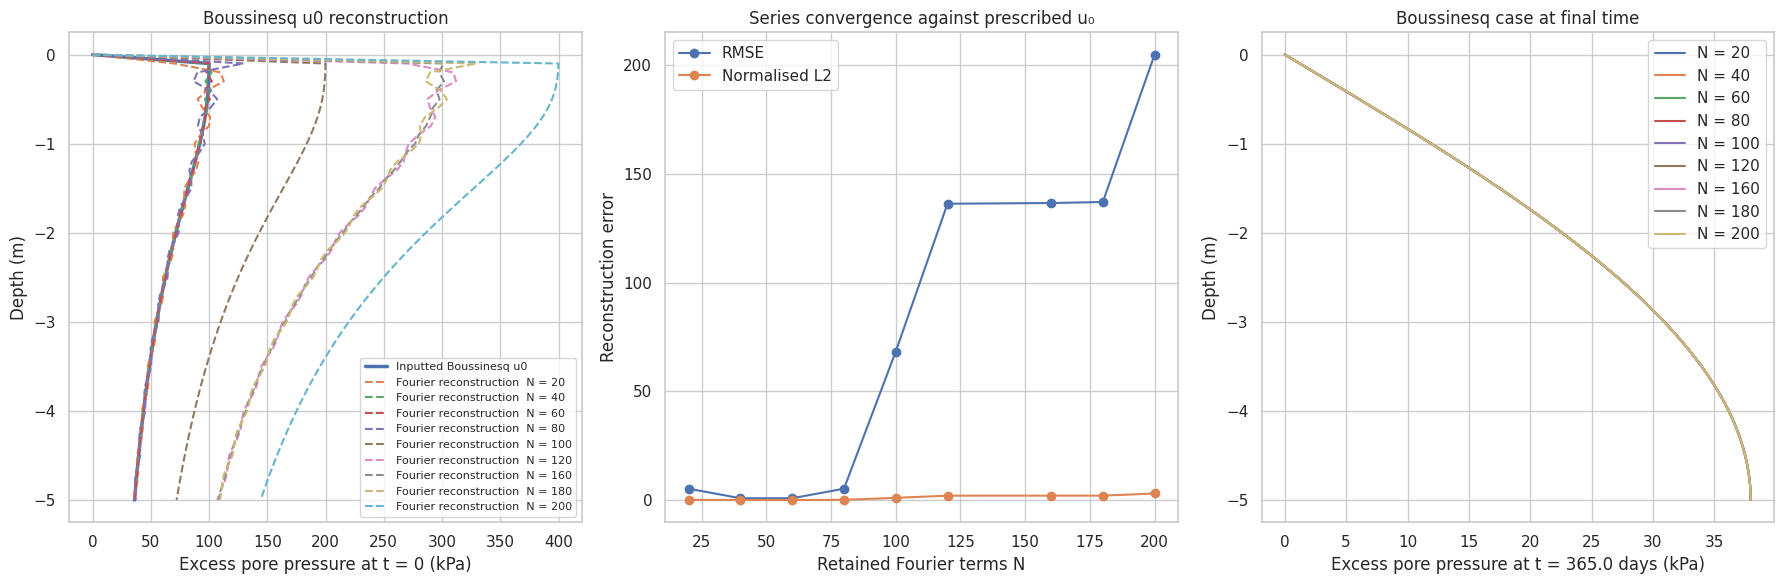

In [19]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].plot(boussinesq_u0, -depth, linewidth=2.5, label="Inputted Boussinesq u0")

for n in n_values:
    axes[0].plot(solutions[n][0], -depth, "--", label=f"Fourier reconstruction  N = {n}")

axes[0].set_xlabel("Excess pore pressure at t = 0 (kPa)")
axes[0].set_ylabel("Depth (m)")
axes[0].set_title("Boussinesq u0 reconstruction")
axes[0].legend(fontsize=8)

axes[1].plot(df_conv.index, df_conv["rmse"],     marker="o", label="RMSE")
axes[1].plot(df_conv.index, df_conv["norm_l2"],  marker="o", label="Normalised L2")
axes[1].set_xlabel("Retained Fourier terms N")
axes[1].set_ylabel("Reconstruction error")
axes[1].set_title("Series convergence against prescribed u₀")
axes[1].legend()

for n in n_values:
    axes[2].plot(solutions[n][-1], -depth, label=f"N = {n}")

axes[2].set_xlabel(f"Excess pore pressure at t = {time_days[-1]:.1f} days (kPa)")
axes[2].set_ylabel("Depth (m)")
axes[2].set_title("Boussinesq case at final time")
axes[2].legend()

plt.tight_layout()
plt.show()

## np.sum vs np.trapezoid — Quadrature Comparison

When computing settlement the strain field must be integrated over depth:

```
s(t) = ∫ Mv * [u₀(z) − u(z,t)] dz
```

The two most common discrete approximations are:

- `np.sum(f * dz)` every point gets weight `dz` 

- `np.trapezoid(f, z)` endpoints get `dz/2`, interior points get `dz` 

### Implication for settlement

For 1D consolidation the surface boundary condition sets u = 0 at z = 0, so f[0] = 0 in every strain integral. The rectangle and trapezoid rules therefore produce the same weight at the surface. The difference only matters at the base (z = H) where the no-flow boundary keeps u > 0. In practice the error is small once the mesh is reasonably fine, but `np.trapezoid` is always the better choice because it converges at O(h²) rather than O(h).